# Migration Playground — Kirchhoff PSTM Validation

**Purpose:** Build intuition for Prestack Time Migration (PSTM) using a fully controlled
synthetic environment. No gprMax data required — everything is generated analytically.

## What this notebook does
1. **Generates** a clean synthetic common-shot gather (CSG) with two overlapping diffraction hyperbolas
2. **Collapses** them with a Kirchhoff summation engine
3. **Quantifies** how well the image focuses (position error + focusing ratio)
4. **Toggles** noise and velocity error so you can develop troubleshooting intuition

## Sections
| # | Cell | Content |
|---|------|---------|
| 1 | Config | Geometry, time axis, medium, toggles |
| 2 | Synthesis | Ricker wavelet + synthetic B-scan |
| 3 | Migration | Kirchhoff PSTM engine |
| 4 | Quality | Focusing metric (position error + FR) |
| 5 | Validation | Two-panel comparison plot |
| 6 | Scenarios | Smiles/frowns physics + `run_experiment()` wrapper |

## Conventions (matches Phase_Analysis_Experiment.ipynb)
| Item | Value / Unit |
|------|--------------|
| Time axis | TWTT [ns], `dt = 0.0018 ns` |
| Space | metres [m], `rx_spacing = 0.02 m` |
| Velocity | m/ns (`c_ice ≈ 0.169 m/ns`) |
| Frequency | GHz (f[GHz] × t[ns] is dimensionless) |
| Trace array | shape `(n_rx, n_time)` — receivers first |
| Image array | shape `(n_z, n_x)` — depth first |
| B-scan cmap | `seismic` |
| Image cmap | `hot_r` |

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert
import time

# ── Acquisition geometry ──────────────────────────────────────────────────
tx_x       = 1.0          # transmitter at centre of spread [m]
n_rx       = 100
rx_start   = 0.02
rx_spacing = 0.02
rx_pos     = rx_start + np.arange(n_rx) * rx_spacing   # (100,) [m]

# ── Time axis ────────────────────────────────────────────────────────────
dt     = 0.0018   # [ns]
n_time = 8000
time_ns = np.arange(n_time) * dt                        # (8000,) [ns]

# ── Medium ───────────────────────────────────────────────────────────────
v_true    = 0.17    # [m/ns]  1.69e8 m/s ≈ 0.17 m/ns
f_central = 1.5     # [GHz]   1.5 GHz GPR source

# ── Scatterers ───────────────────────────────────────────────────────────
targets = [
    {'x': 1.0, 'z': 0.5, 'label': 'T1'},
    {'x': 1.5, 'z': 0.8, 'label': 'T2'},
]

# ── Migration image grid ─────────────────────────────────────────────────
x_img = np.linspace(0.0, 2.0, 200)   # (200,) [m]
z_img = np.linspace(0.0, 1.2, 120)   # (120,) [m]

# ── Complexity toggles ───────────────────────────────────────────────────
ADD_NOISE          = False
NOISE_SNR_DB       = 20.0

USE_VELOCITY_ERROR = False
VELOCITY_ERROR_PCT = +10.0   # positive → smiles; negative → frowns

v_migration = v_true * (1.0 + VELOCITY_ERROR_PCT / 100.0) if USE_VELOCITY_ERROR else v_true

# ── Confirm parameters ───────────────────────────────────────────────────
print(f't_max      = {time_ns[-1]:.3f} ns  (expected ≈ 14.4 ns)')
print(f'x_rx range = {rx_pos[0]:.2f} – {rx_pos[-1]:.2f} m')
print(f'v_true     = {v_true} m/ns')
print(f'v_migration= {v_migration:.4f} m/ns  (error {VELOCITY_ERROR_PCT:+.1f}%)')
print(f'ADD_NOISE  = {ADD_NOISE}  |  SNR = {NOISE_SNR_DB} dB')
for t in targets:
    r_tx = np.sqrt((t['x'] - tx_x)**2 + t['z']**2)
    t_apex = (r_tx + t['z']) / v_true
    print(f"  {t['label']} ({t['x']}, {t['z']}) m  →  apex TWTT ≈ {t_apex:.2f} ns")

t_max      = 14.398 ns  (expected ≈ 14.4 ns)
x_rx range = 0.02 – 2.00 m
v_true     = 0.17 m/ns
v_migration= 0.1700 m/ns  (error +10.0%)
ADD_NOISE  = False  |  SNR = 20.0 dB
  T1 (1.0, 0.5) m  →  apex TWTT ≈ 5.88 ns
  T2 (1.5, 0.8) m  →  apex TWTT ≈ 10.26 ns


bscan.shape = (100, 8000)  (expected (100, 8000))


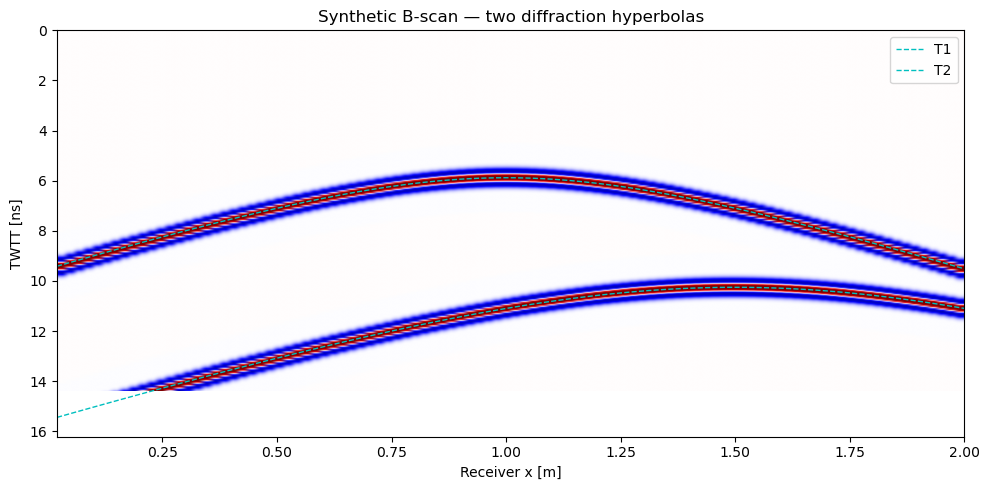

In [9]:
# ── Ricker wavelet ────────────────────────────────────────────────────────
def ricker_wavelet(t_ns, t0_ns, f_ghz):
    '''Zero-phase Ricker.  f[GHz] * t[ns] is dimensionless — no unit conversion needed.'''
    tau = t_ns - t0_ns
    u   = (np.pi * f_ghz * tau) ** 2
    return (1.0 - 2.0 * u) * np.exp(-u)


# ── Synthetic B-scan ──────────────────────────────────────────────────────
def make_synthetic_bscan(time_ns, tx_x, rx_pos, targets, v_mns, f_ghz,
                          add_noise=False, snr_db=20.0):
    '''Build a (n_rx, n_time) synthetic CSG with Ricker-wavelet reflections.

    For each scatterer at (x_s, z_s) and each receiver x_r:
        r_tx = sqrt((x_s - tx_x)^2 + z_s^2)          [m]
        r_rx = sqrt((x_s - rx_pos)^2 + z_s^2)         (n_rx,) [m]
        t_arrival = (r_tx + r_rx) / v_mns             (n_rx,) [ns]
    '''
    n_rx   = len(rx_pos)
    n_time = len(time_ns)
    bscan  = np.zeros((n_rx, n_time))

    for tgt in targets:
        x_s, z_s = tgt['x'], tgt['z']
        r_tx = np.sqrt((x_s - tx_x)**2 + z_s**2)              # scalar [m]
        r_rx = np.sqrt((x_s - rx_pos)**2 + z_s**2)            # (n_rx,) [m]
        t_arr = (r_tx + r_rx) / v_mns                          # (n_rx,) [ns]
        for i, t0 in enumerate(t_arr):
            bscan[i] += ricker_wavelet(time_ns, t0, f_ghz)

    if add_noise:
        rng       = np.random.default_rng(42)
        sig_rms   = np.sqrt(np.mean(bscan**2))
        noise_rms = sig_rms / (10.0 ** (snr_db / 20.0))
        bscan    += rng.normal(0.0, noise_rms, bscan.shape)

    # normalise to peak amplitude 1
    peak = np.max(np.abs(bscan))
    if peak > 0:
        bscan /= peak
    return bscan


# ── Generate and preview ──────────────────────────────────────────────────
bscan = make_synthetic_bscan(time_ns, tx_x, rx_pos, targets,
                              v_true, f_central,
                              add_noise=ADD_NOISE, snr_db=NOISE_SNR_DB)
print(f'bscan.shape = {bscan.shape}  (expected (100, 8000))')

p98   = np.percentile(np.abs(bscan), 98)
fig, ax = plt.subplots(figsize=(10, 5))
ax.imshow(bscan.T, aspect='auto', cmap='seismic',
          vmin=-p98, vmax=p98,
          extent=[rx_pos[0], rx_pos[-1], time_ns[-1], time_ns[0]],
          origin='upper')
for tgt in targets:
    r_tx = np.sqrt((tgt['x'] - tx_x)**2 + tgt['z']**2)
    r_rx = np.sqrt((tgt['x'] - rx_pos)**2 + tgt['z']**2)
    t_hyp = (r_tx + r_rx) / v_true
    ax.plot(rx_pos, t_hyp, 'c--', lw=1.0, label=tgt['label'])
ax.set_xlabel('Receiver x [m]')
ax.set_ylabel('TWTT [ns]')
ax.set_title('Synthetic B-scan — two diffraction hyperbolas')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [10]:
# ── Kirchhoff PSTM ────────────────────────────────────────────────────────
def kirchhoff_pstm(bscan, time_ns, tx_x, rx_pos, v_mns, x_img, z_img,
                   max_angle_deg=70.0, apply_obliquity=True):
    '''Kirchhoff prestack time migration.  Returns image shape (n_z, n_x).

    Outer loop: (iz, ix) — 24 000 Python iterations.
    Inner op  : fully vectorised over n_rx=100 receivers (numpy fancy index).
    Aperture  : cos(theta) >= cos(max_angle_deg) mutes near-horizontal energy.
    Obliquity : w = 0.5*(cos_tx + cos_rx) — standard Kirchhoff correction.
    '''
    dt_ns   = time_ns[1] - time_ns[0]
    n_time  = len(time_ns)
    n_rx    = len(rx_pos)
    n_z     = len(z_img)
    n_x     = len(x_img)
    cos_max = np.cos(np.radians(max_angle_deg))
    rx_idx  = np.arange(n_rx, dtype=np.int32)

    image = np.zeros((n_z, n_x))

    t0_perf = time.perf_counter()
    for iz, z_out in enumerate(z_img):
        for ix, x_out in enumerate(x_img):
            # travel times
            r_tx  = np.sqrt((x_out - tx_x)**2 + z_out**2)          # scalar
            r_rx  = np.sqrt((x_out - rx_pos)**2 + z_out**2)         # (n_rx,)
            t_sum = (r_tx + r_rx) / v_mns                           # (n_rx,) [ns]

            # sample indices (nearest-neighbour)
            t_idx = np.round((t_sum - time_ns[0]) / dt_ns).astype(np.int32)

            # aperture mute
            cos_tx  = z_out / r_tx if r_tx > 0 else 0.0
            cos_rx  = z_out / r_rx                                   # (n_rx,)
            valid   = (t_idx >= 0) & (t_idx < n_time) & (cos_rx >= cos_max)

            if not valid.any():
                continue

            # gather amplitudes
            amps = bscan[rx_idx[valid], t_idx[valid]]               # (n_valid,)

            if apply_obliquity:
                w = 0.5 * (cos_tx + cos_rx[valid])
                image[iz, ix] = np.sum(w * amps)
            else:
                image[iz, ix] = np.sum(amps)

    elapsed = time.perf_counter() - t0_perf
    print(f'Migration complete in {elapsed:.1f} s')
    return image


# ── Run migration ─────────────────────────────────────────────────────────
migrated = kirchhoff_pstm(bscan, time_ns, tx_x, rx_pos, v_migration,
                           x_img, z_img)
print(f'migrated.shape = {migrated.shape}  (expected (120, 200))')

C:\Users\Administrator\AppData\Local\Temp\ipykernel_9088\3148607257.py:34: RuntimeWarning: invalid value encountered in divide
  cos_rx  = z_out / r_rx                                   # (n_rx,)


Migration complete in 0.6 s
migrated.shape = (120, 200)  (expected (120, 200))


In [11]:
# ── Focusing quality metric ───────────────────────────────────────────────
def focusing_quality(migrated, x_img, z_img, targets,
                     search_radius_m=0.15, peak_box_pixels=3):
    '''Per-target: position error (m) + focusing ratio FR = E_window / E_total.

    Steps:
      1. Hilbert envelope along depth axis → env (n_z, n_x)
      2. For each target: search ±search_radius_m window around true (x_t, z_t)
      3. Find peak pixel → (x_peak, z_peak)
      4. pos_error = distance(peak, true)  [m]
      5. FR = E(±peak_box_pixels box) / E_total
    '''
    env    = np.abs(hilbert(migrated, axis=0))   # envelope along depth
    E_tot  = np.sum(env**2) + 1e-30
    dx     = x_img[1] - x_img[0]
    dz     = z_img[1] - z_img[0]
    results = []

    for tgt in targets:
        x_t, z_t = tgt['x'], tgt['z']

        # pixel window around true position
        ix_c = np.argmin(np.abs(x_img - x_t))
        iz_c = np.argmin(np.abs(z_img - z_t))
        r_px_x = int(np.ceil(search_radius_m / dx))
        r_px_z = int(np.ceil(search_radius_m / dz))

        ix_lo = max(0, ix_c - r_px_x)
        ix_hi = min(len(x_img) - 1, ix_c + r_px_x)
        iz_lo = max(0, iz_c - r_px_z)
        iz_hi = min(len(z_img) - 1, iz_c + r_px_z)

        window = env[iz_lo:iz_hi+1, ix_lo:ix_hi+1]
        pk_flat = np.argmax(window)
        pk_iz, pk_ix = np.unravel_index(pk_flat, window.shape)
        pk_iz += iz_lo
        pk_ix += ix_lo

        x_peak = x_img[pk_ix]
        z_peak = z_img[pk_iz]
        pos_err = np.sqrt((x_peak - x_t)**2 + (z_peak - z_t)**2)

        # focusing ratio — energy in small box vs total
        bx_lo_z = max(0, pk_iz - peak_box_pixels)
        bx_hi_z = min(len(z_img) - 1, pk_iz + peak_box_pixels)
        bx_lo_x = max(0, pk_ix - peak_box_pixels)
        bx_hi_x = min(len(x_img) - 1, pk_ix + peak_box_pixels)
        E_box = np.sum(env[bx_lo_z:bx_hi_z+1, bx_lo_x:bx_hi_x+1]**2)
        FR    = E_box / E_tot

        results.append({
            'label'       : tgt['label'],
            'x_true'      : x_t,
            'z_true'      : z_t,
            'x_peak'      : x_peak,
            'z_peak'      : z_peak,
            'pos_error_m' : pos_err,
            'focusing_ratio': FR,
        })

    # print table
    print(f'{'Label':<6} {'True (x,z)':<16} {'Peak (x,z)':<16} {'Err [cm]':>9} {'FR':>8}')
    print('-' * 60)
    for r in results:
        print(f"{r['label']:<6} ({r['x_true']:.2f},{r['z_true']:.2f})        "
              f"({r['x_peak']:.3f},{r['z_peak']:.3f})    "
              f"{r['pos_error_m']*100:>7.2f}  {r['focusing_ratio']:>8.5f}")
    return results


# ── Evaluate ──────────────────────────────────────────────────────────────
fq_results = focusing_quality(migrated, x_img, z_img, targets)

Label  True (x,z)       Peak (x,z)        Err [cm]       FR
------------------------------------------------------------
T1     (1.00,0.50)        (0.995,0.504)       0.66   0.32908
T2     (1.50,0.80)        (1.497,0.797)       0.42   0.31663


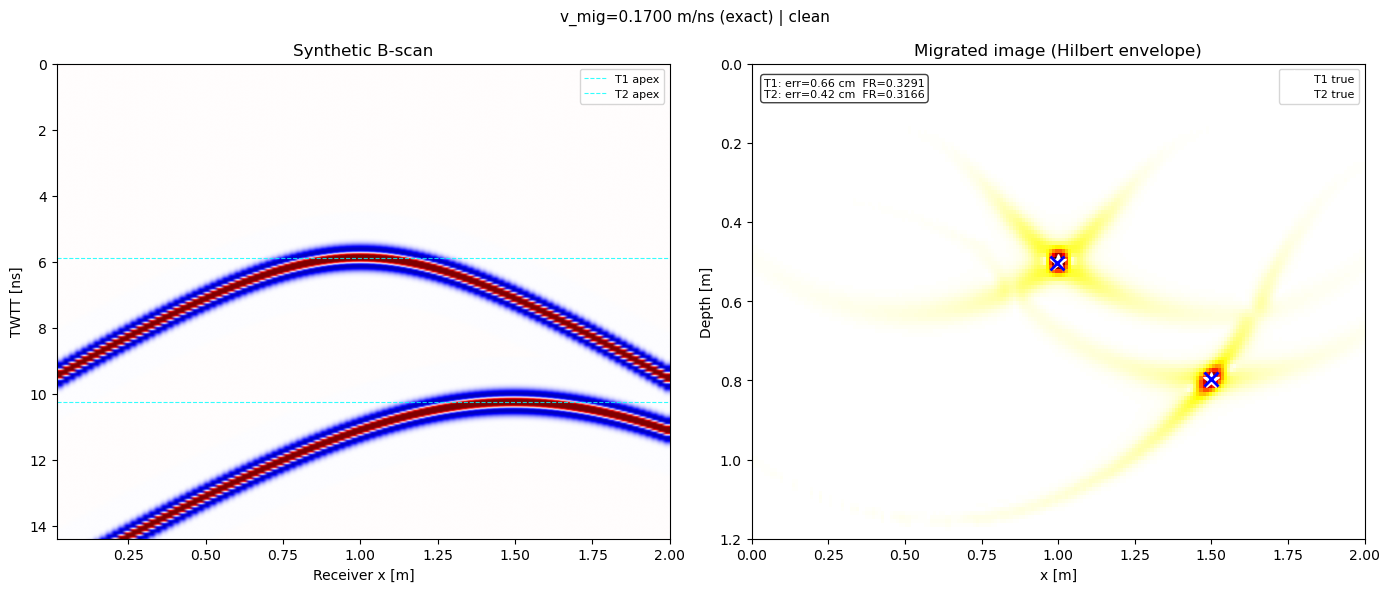

In [12]:
# ── Validation plot ───────────────────────────────────────────────────────
def plot_validation(bscan, migrated, time_ns, rx_pos, x_img, z_img,
                    targets, fq_results, v_migration, v_true,
                    add_noise, use_vel_error, vel_error_pct):
    '''Two-panel (14,6): seismic B-scan (left) | hot_r migrated envelope (right).'''
    env_mig = np.abs(hilbert(migrated, axis=0))

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # ── Left: raw B-scan ─────────────────────────────────────────────────
    ax = axes[0]
    p98 = np.percentile(np.abs(bscan), 98)
    ax.imshow(bscan.T, aspect='auto', cmap='seismic',
              vmin=-p98, vmax=p98,
              extent=[rx_pos[0], rx_pos[-1], time_ns[-1], time_ns[0]],
              origin='upper')
    for tgt in targets:
        r_tx  = np.sqrt((tgt['x'] - tx_x)**2 + tgt['z']**2)
        t_apex = (r_tx + tgt['z']) / v_true   # CSG apex: min TWTT at rx=x_target
        ax.axhline(t_apex, color='cyan', lw=0.8, ls='--', alpha=0.8,
                   label=f"{tgt['label']} apex")
    ax.set_xlabel('Receiver x [m]')
    ax.set_ylabel('TWTT [ns]')
    ax.set_title('Synthetic B-scan')
    ax.legend(fontsize=8, loc='upper right')

    # ── Right: migrated envelope ──────────────────────────────────────────
    ax = axes[1]
    ax.imshow(env_mig, aspect='auto', cmap='hot_r', vmin=0,
              extent=[x_img[0], x_img[-1], z_img[-1], z_img[0]],
              origin='upper')

    # true positions
    for tgt in targets:
        ax.plot(tgt['x'], tgt['z'], 'w*', ms=12, label=f"{tgt['label']} true")

    # detected peaks + FR annotation
    fr_lines = []
    for r in fq_results:
        ax.plot(r['x_peak'], r['z_peak'], 'bx', ms=10, mew=2)
        fr_lines.append(f"{r['label']}: err={r['pos_error_m']*100:.2f} cm  FR={r['focusing_ratio']:.4f}")
    textbox = '\n'.join(fr_lines)
    ax.text(0.02, 0.97, textbox, transform=ax.transAxes,
            fontsize=8, va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.75))

    ax.set_xlabel('x [m]')
    ax.set_ylabel('Depth [m]')
    ax.set_title('Migrated image (Hilbert envelope)')
    ax.legend(fontsize=8, loc='upper right')

    # figure title encodes toggle state
    v_err_str = f'{vel_error_pct:+.1f}%' if use_vel_error else 'exact'
    noise_str = f'SNR={NOISE_SNR_DB:.0f} dB' if add_noise else 'clean'
    fig.suptitle(f'v_mig={v_migration:.4f} m/ns ({v_err_str}) | {noise_str}',
                 fontsize=11)
    plt.tight_layout()
    plt.show()
    return fig


fig = plot_validation(bscan, migrated, time_ns, rx_pos, x_img, z_img,
                      targets, fq_results, v_migration, v_true,
                      ADD_NOISE, USE_VELOCITY_ERROR, VELOCITY_ERROR_PCT)

## Migration Velocity Errors — Smiles and Frowns

### Why velocity errors distort the image

Kirchhoff migration sums energy along a **diffraction traveltime curve** computed from `v_migration`.
When `v_migration ≠ v_true`, the summation curve no longer matches the actual hyperbola in the data:

| Condition | Effect in migrated image | Name |
|-----------|--------------------------|------|
| `v_mig > v_true` | Summation curve is **too wide** → energy from off-flank samples dragged upward at the edges | **Smiles** |
| `v_mig < v_true` | Summation curve is **too narrow** → flanks of the hyperbola not fully collapsed | **Frowns** (residual hyperbola) |
| `v_mig = v_true` | Perfect collapse → compact bright dot | |

### Diagnostic: Focusing Ratio (FR)

FR = energy in a small box around the peak / total image energy.  
A well-focused image concentrates energy → **high FR**.  
Over- or under-migration spreads energy → **lower FR**.

Use `run_experiment()` below to compare scenarios side-by-side.

--- Experiment: noise=False, SNR=20.0 dB, vel_err=+0.0% ---


C:\Users\Administrator\AppData\Local\Temp\ipykernel_9088\3148607257.py:34: RuntimeWarning: invalid value encountered in divide
  cos_rx  = z_out / r_rx                                   # (n_rx,)


Migration complete in 0.6 s
Label  True (x,z)       Peak (x,z)        Err [cm]       FR
------------------------------------------------------------
T1     (1.00,0.50)        (0.995,0.504)       0.66   0.32908
T2     (1.50,0.80)        (1.497,0.797)       0.42   0.31663


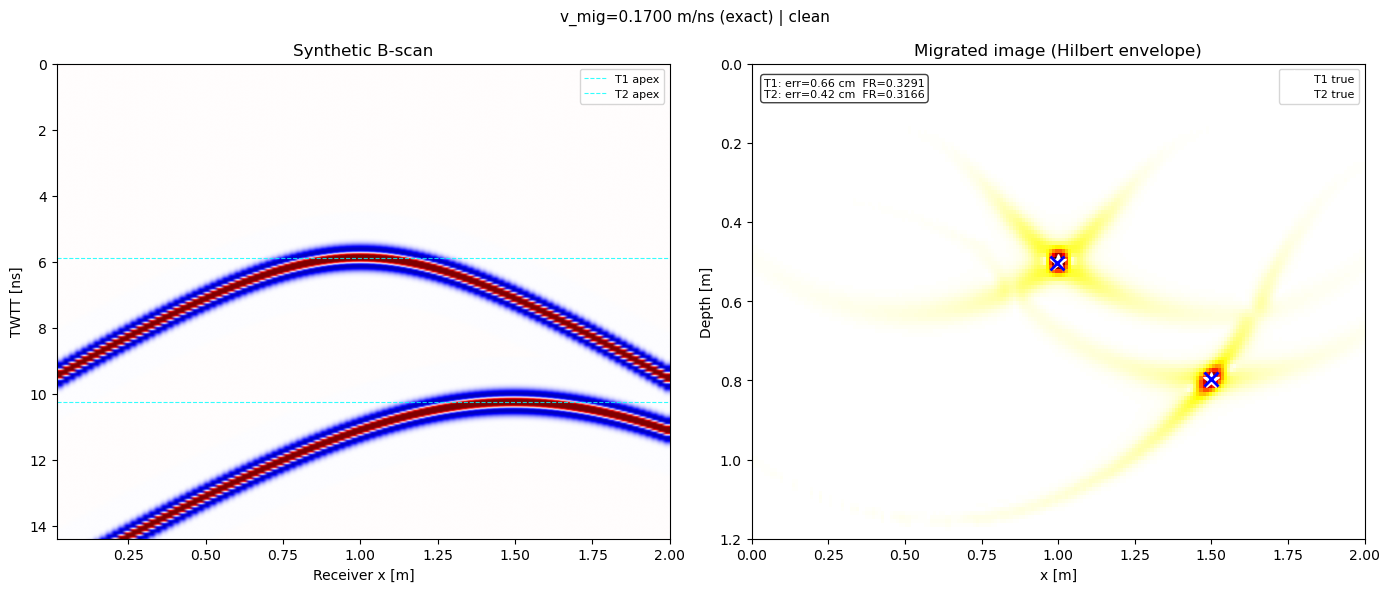

--- Experiment: noise=True, SNR=20.0 dB, vel_err=+0.0% ---
Migration complete in 0.6 s
Label  True (x,z)       Peak (x,z)        Err [cm]       FR
------------------------------------------------------------
T1     (1.00,0.50)        (1.005,0.504)       0.66   0.32863
T2     (1.50,0.80)        (1.497,0.797)       0.42   0.31600


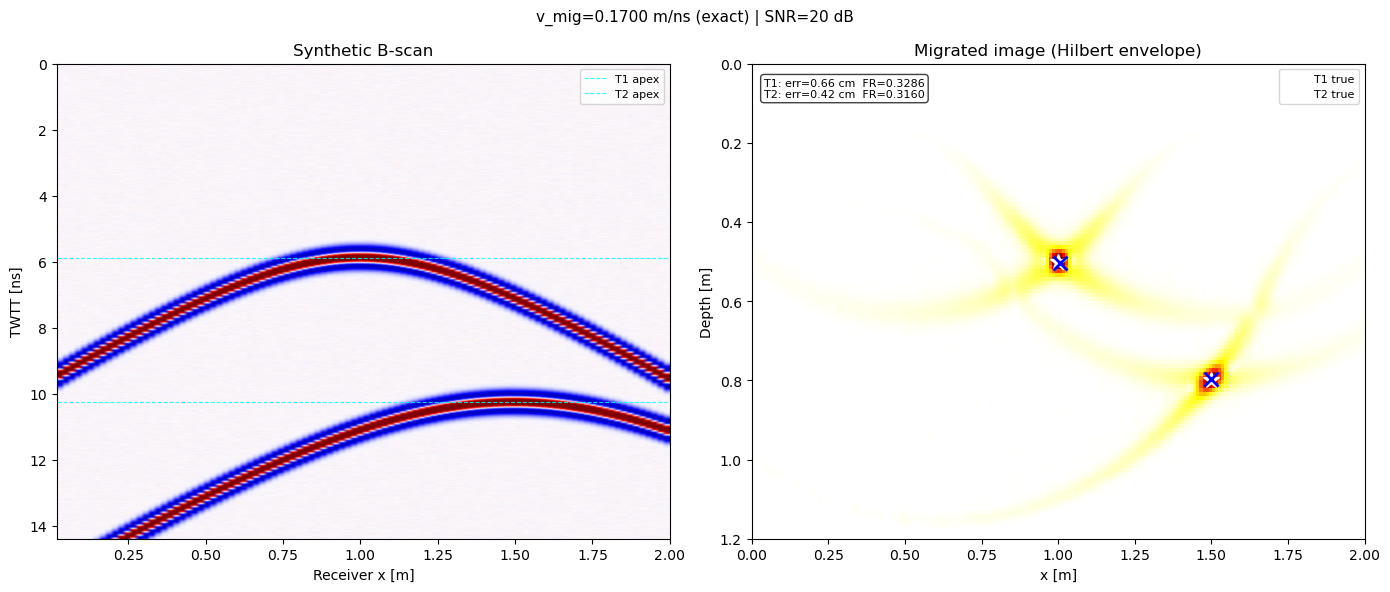

--- Experiment: noise=False, SNR=20.0 dB, vel_err=+10.0% ---
Migration complete in 0.6 s
Label  True (x,z)       Peak (x,z)        Err [cm]       FR
------------------------------------------------------------
T1     (1.00,0.50)        (1.045,0.545)       6.35   0.07587
T2     (1.50,0.80)        (1.528,0.887)       9.17   0.10636


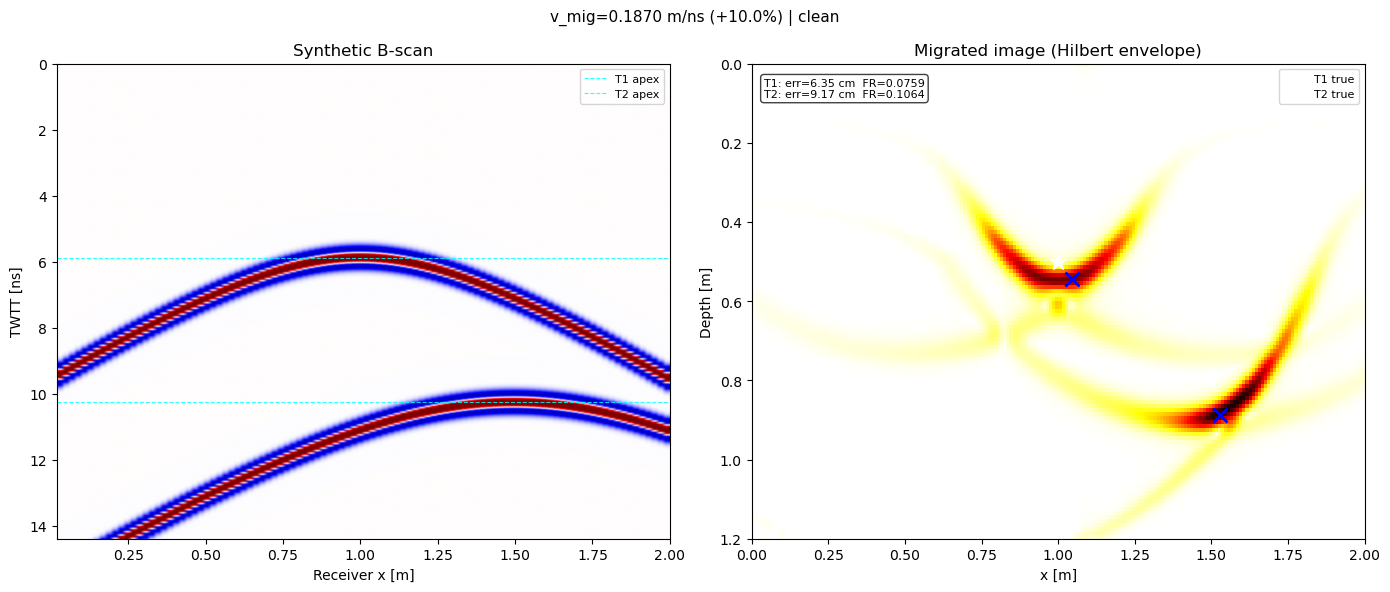

--- Experiment: noise=False, SNR=20.0 dB, vel_err=-10.0% ---
Migration complete in 0.6 s
Label  True (x,z)       Peak (x,z)        Err [cm]       FR
------------------------------------------------------------
T1     (1.00,0.50)        (1.106,0.464)      11.15   0.07615
T2     (1.50,0.80)        (1.387,0.756)      12.12   0.11397


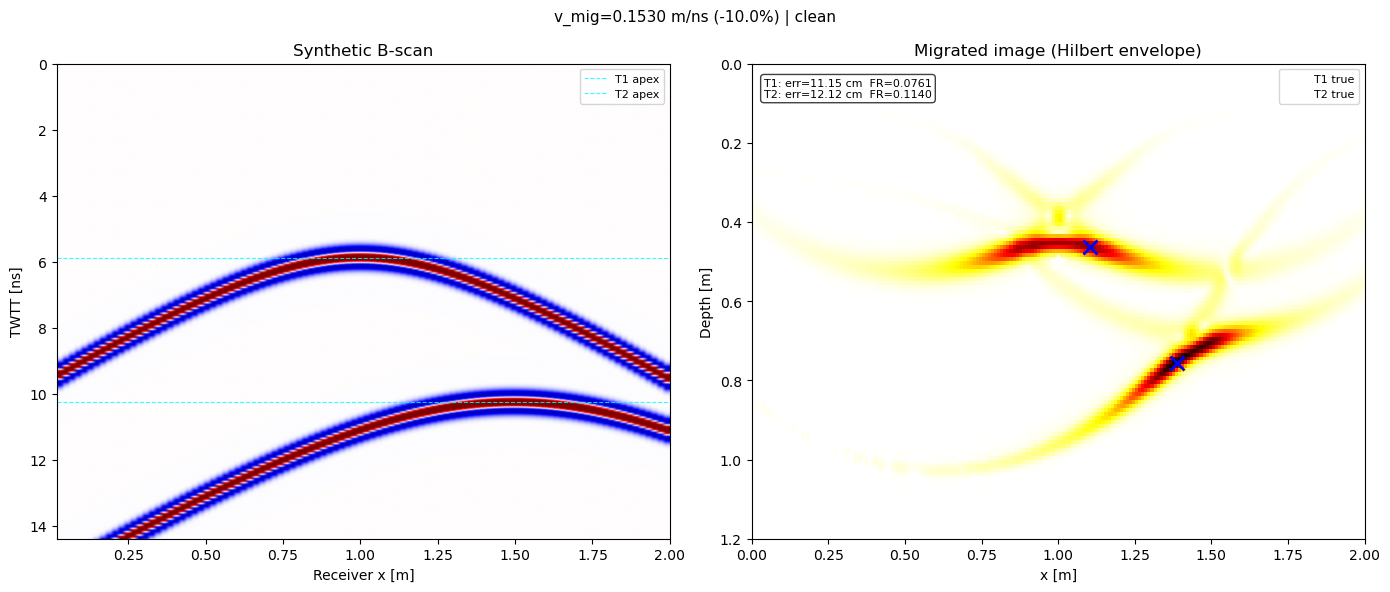

(<Figure size 1400x600 with 2 Axes>,
 [{'label': 'T1',
   'x_true': 1.0,
   'z_true': 0.5,
   'x_peak': np.float64(1.105527638190955),
   'z_peak': np.float64(0.46386554621848736),
   'pos_error_m': np.float64(0.11154273249409553),
   'focusing_ratio': np.float64(0.07614701143791301)},
  {'label': 'T2',
   'x_true': 1.5,
   'z_true': 0.8,
   'x_peak': np.float64(1.3869346733668342),
   'z_peak': np.float64(0.7563025210084032),
   'pos_error_m': np.float64(0.12121566630137179),
   'focusing_ratio': np.float64(0.11396599086015617)}])

In [14]:
# ── Scenario wrapper ──────────────────────────────────────────────────────
def run_experiment(add_noise=False, noise_snr_db=20.0, vel_error_pct=0.0):
    '''Full pipeline: generate → migrate → quality → plot.

    Parameters
    ----------
    add_noise     : bool   — add white Gaussian noise (SNR = noise_snr_db)
    noise_snr_db  : float  — signal-to-noise ratio in dB
    vel_error_pct : float  — velocity error %  (+10 → smiles, -10 → frowns)
    '''
    use_vel_err = (vel_error_pct != 0.0)
    v_mig = v_true * (1.0 + vel_error_pct / 100.0)

    print(f'--- Experiment: noise={add_noise}, SNR={noise_snr_db} dB, '
          f'vel_err={vel_error_pct:+.1f}% ---')

    b = make_synthetic_bscan(time_ns, tx_x, rx_pos, targets,
                              v_true, f_central,
                              add_noise=add_noise, snr_db=noise_snr_db)

    m = kirchhoff_pstm(b, time_ns, tx_x, rx_pos, v_mig, x_img, z_img)

    fq = focusing_quality(m, x_img, z_img, targets)

    fig = plot_validation(b, m, time_ns, rx_pos, x_img, z_img,
                          targets, fq, v_mig, v_true,
                          add_noise, use_vel_err, vel_error_pct)
    return fig, fq


# ── Uncomment one or more scenarios ──────────────────────────────────────

# Scenario A — clean data, exact velocity (baseline)
run_experiment(add_noise=False, vel_error_pct=0.0)

# Scenario B — noisy data, exact velocity
run_experiment(add_noise=True, noise_snr_db=20.0, vel_error_pct=0.0)

# Scenario C — clean data, +10% velocity → smiles
run_experiment(add_noise=False, vel_error_pct=+10.0)

# Scenario D — clean data, -10% velocity → frowns
run_experiment(add_noise=False, vel_error_pct=-10.0)